In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
import os
from att_tools import pred2label_ref, copy_files_list
from yolo_mask_crop import myolo_crop
from data_vis.yolo_sta import yolo_sta


In [ ]:
base_dir = r'/localnvme/data/billboard/fused_data/data7961_mseg_c5_l2_1029_abandonment_refine'
ana_dir = os.path.join(base_dir, 'result_analysis', 'keep', 'pred_no_label_background')

data1106_dir = r'/localnvme/data/billboard/fused_data/data7961_mseg_c5_l2_1029_abandonment_refine/result_analysis/keep/pred_no_label_background/merge_1106'
data1106_dir_all = os.path.join(data1106_dir, 'all')
data1106_dir_with_defect = os.path.join(data1106_dir, 'all_with_risk')
data1106_dir_with_defect_update = os.path.join(data1106_dir, 'all_with_risk_update')
data1106_dir_without_defect = os.path.join(data1106_dir, 'all_without_risk')
data1106_label_dir = data1106_dir+'_labels'
data1106_dir_no = os.path.join(data1106_dir, 'no')
risks = ['deformation','broken', 'abandonment', 'corrosion']

In [ ]:

pred_high_label_background_dir = os.path.join(data1106_dir, 'pred_high_label_background')
pred_medium_label_background_dir = os.path.join(data1106_dir, 'pred_medium_label_background')
for risk in risks:
    ph_lb_r = os.path.join(pred_high_label_background_dir, f'risk_{risk}_pred_high_label_background')
    pm_lb_r = os.path.join(pred_medium_label_background_dir, f'risk_{risk}_pred_medium_label_background')
    copy_files_list([ph_lb_r, pm_lb_r], data1106_dir_with_defect)

In [ ]:
copy_files_list(data1106_dir_with_defect, data1106_dir_all)
copy_files_list(data1106_dir_without_defect, data1106_dir_all)

In [ ]:
pred2label_ref(
    r'/localnvme/project/ultralytics/runs/msegment/val694/labels',
    data1106_dir_all,
    data1106_label_dir,
    ref_dir = data1106_dir,
    attributes=r'/localnvme/data/billboard/fused_data/data7961_mseg_c5_l2_1029_abandonment_refine/attribute.yaml',
)

In [ ]:
base_dir = r'/localnvme/data/billboard/fused_data/data7961_mseg_c5_l2_1029_abandonment_refine'
image_dir = os.path.join(base_dir, 'images')
label_dir_root = os.path.join(base_dir, 'result_analysis', 'keep', 'pred_no_label_background')
label_dir = os.path.join(label_dir_root, 'merge_1106_labels')
label_sta_dir = os.path.join(label_dir_root, 'merge_1106_labels_sta')
image_crop_dir = os.path.join(label_dir_root, 'merge_1106_labels_crop')
attribute_file = os.path.join(base_dir, 'attribute.yaml')
class_file = os.path.join(base_dir, 'class.txt')


In [ ]:
myolo_crop(image_dir, data1106_label_dir, image_crop_dir, class_file,
           attribute_file=attribute_file, seg=True, annotation=False,
           save_method='attribute', only_defect=True, with_boundary=False,
           crop_method='with_background_box_shape')

In [ ]:
# risk check result merge

In [ ]:
import shutil
from att_tools import labels_merge
from yolo_tools import copy_all, copy_split,data_tf_pipline_new

In [ ]:
input_dir = r'/localnvme/data/billboard/all_data/mseg_c6/data7961_mseg_c6_1030'
class_c6_path = r'/localnvme/data/billboard/class_c6.txt'
class_c5_path = r'/localnvme/data/billboard/class_c5.txt'
att_l3_path = r'/localnvme/data/billboard/attribute.yaml'
att_l2_path = r'/localnvme/data/billboard/attribute_l2.yaml'
input_train_test_path = os.path.join(input_dir, 'train_test.txt')
input_val_test_path = os.path.join(input_dir, 'val_test.txt')
input_train_80p_path = os.path.join(input_dir, 'train_80p_ref.txt')
input_val_80p_path = os.path.join(input_dir, 'val_80p_ref.txt')
input_all_path = os.path.join(input_dir, 'all.txt')
input_all_test_path = os.path.join(input_dir, 'all_test.txt')
input_image_dir = os.path.join(input_dir, 'images')
input_label_v5_dir = os.path.join(input_dir, 'labels_v5')
input_label_v6_dir = os.path.join(input_dir, 'labels_v6')
input_label_v10_dir = os.path.join(input_dir, 'labels_v10')


datav6_dir =  r'/localnvme/data/billboard/all_data/mseg_c6/data7961_mseg_c6_1104_v6'
datav10_dir =  r'/localnvme/data/billboard/all_data/mseg_c6/data7961_mseg_c6_1106_v10'

In [ ]:
labels_merge(input_label_v6_dir, data1106_label_dir, input_label_v10_dir)

In [ ]:
copy_all(
    input_label_v10_dir,
    os.path.join(datav10_dir, 'labels'),
    input_image_dir,
    os.path.join(datav10_dir, 'images'),
)

In [ ]:
yolo_sta(
    # img_dir=os.path.join(dataset_dir, "images"),
    gt_dir=label_dir,
    result_dir=label_sta_dir,
    class_path=class_file,
    attribute_path=attribute_file,
    seg=True,
)

In [ ]:
output_dir = datav10_dir
output_train_test_path = os.path.join(output_dir, 'train_test.txt')
output_val_test_path = os.path.join(output_dir, 'val_test.txt')
output_train_80p_path = os.path.join(output_dir, 'train_80p_ref.txt')
output_val_80p_path = os.path.join(output_dir, 'val_80p_ref.txt')
output_all_path = os.path.join(output_dir, 'all.txt')
output_all_test_path = os.path.join(output_dir, 'all_test.txt')

copy_split(input_train_test_path, output_train_test_path)
copy_split(input_val_test_path, output_val_test_path)
copy_split(input_train_80p_path, output_train_80p_path)
copy_split(input_val_80p_path, output_val_80p_path)
copy_split(input_all_path, output_all_path)
copy_split(input_all_test_path, output_all_test_path)

shutil.copy(class_c6_path, os.path.join(output_dir, 'class.txt'))
shutil.copy(att_l3_path, os.path.join(output_dir, 'attribute.yaml'))

In [ ]:
data_tf_pipline_new(datav10_dir, copy_list=['mseg_c5_l2', 'seg_c5'])

In [ ]:
output_dir = datav10_dir.replace('mseg_c6', 'mseg_c5_l2')
output_train_test_path = os.path.join(output_dir, 'train_test.txt')
output_val_test_path = os.path.join(output_dir, 'val_test.txt')
output_train_80p_path = os.path.join(output_dir, 'train_80p_ref.txt')
output_val_80p_path = os.path.join(output_dir, 'val_80p_ref.txt')
output_all_path = os.path.join(output_dir, 'all.txt')
output_all_test_path = os.path.join(output_dir, 'all_test.txt')

copy_split(input_train_test_path, output_train_test_path, abs_path=True)
copy_split(input_val_test_path, output_val_test_path, abs_path=True)
copy_split(input_train_80p_path, output_train_80p_path, abs_path=True)
copy_split(input_val_80p_path, output_val_80p_path, abs_path=True)
copy_split(input_all_path, output_all_path, abs_path=True)
copy_split(input_all_test_path, output_all_test_path, abs_path=True)

In [ ]:
# category check

In [1]:
import os
import shutil
from data_vis.yolo_sta import yolo_sta
from att_tools import category_update_by_ref
from yolo_tools import copy_all, copy_split, data_tf_pipline_new

In [11]:
base_dir = r'/localnvme/data/billboard/all_data/mseg_c6/data7961_mseg_c6_1030'
image_dir = os.path.join(base_dir, 'images')
label_dir = os.path.join(base_dir, 'labels_v10')
label_ana_dir = os.path.join(base_dir, 'labels_analysis')
label_sta_dir = os.path.join(label_ana_dir, 'gt_sta_v10')
image_crop_dir = os.path.join(label_ana_dir, 'all_gt_v10')
attribute_file = os.path.join(base_dir, 'attribute.yaml')
class_file = os.path.join(base_dir, 'class.txt')
class_c6_path = r'/localnvme/data/billboard/class_c6.txt'
class_c5_path = r'/localnvme/data/billboard/class_c5.txt'
att_l3_path = r'/localnvme/data/billboard/attribute.yaml'
att_l2_path = r'/localnvme/data/billboard/attribute_l2.yaml'
input_dir = base_dir
input_train_test_path = os.path.join(input_dir, 'train_test.txt')
input_val_test_path = os.path.join(input_dir, 'val_test.txt')
input_train_80p_path = os.path.join(input_dir, 'train_80p_ref.txt')
input_val_80p_path = os.path.join(input_dir, 'val_80p_ref.txt')
input_all_path = os.path.join(input_dir, 'all.txt')
input_all_test_path = os.path.join(input_dir, 'all_test.txt')
label_v10_dir = os.path.join(base_dir, 'labels_v10')
label_v12_dir = os.path.join(base_dir, 'labels_v12')
check_dir = r'/localnvme/data/billboard/all_data/mseg_c6/data7961_mseg_c6_1030/labels_analysis/all_gt_v10_category_corrrect'
datav12_dir =  r'/localnvme/data/billboard/all_data/mseg_c6/data7961_mseg_c6_1106_v12'


In [ ]:
# yolo_sta(
#     # img_dir=os.path.join(dataset_dir, "images"),
#     gt_dir=label_dir,
#     result_dir=label_sta_dir,
#     class_path=class_file,
#     attribute_path=attribute_file,
#     seg=True,
# )

In [ ]:
# myolo_crop(image_dir, label_dir, image_crop_dir, class_file,
#            attribute_file=attribute_file, seg=True, annotation=False,
#            save_method='category', only_defect=False, with_boundary=True,
#            crop_method='with_background_box_shape')

In [ ]:
# merge category check results

In [3]:
category_update_by_ref(label_v10_dir,label_v12_dir,check_dir,class_file,)

load wall frame: 0it [00:00, ?it/s]
load no: 100%|██████████| 54/54 [00:00<00:00, 60738.11it/s]


load 339/436 records,


update label: 100%|██████████| 7946/7946 [00:00<00:00, 10578.27it/s]

change 339/436 records, total 7946 records,


In [4]:
yolo_sta(
    gt_dir=label_v10_dir,
    result_dir=label_v10_dir+'_sta',
    class_path=class_file,
    attribute_path=attribute_file,
    seg=True,
)

label read:   9%|▉         | 701/7946 [00:03<00:39, 182.20it/s]


KeyboardInterrupt: 

label read: 100%|██████████| 7946/7946 [00:40<00:00, 196.11it/s]


get 7946 labels, merging...


/localnvme/project/dataset_tools/data_vis/yolo_sta.py:303: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  dfs = pd.concat(dfs)


merging finish, get 61862 labels!
csv save to /localnvme/data/billboard/all_data/mseg_c6/data7961_mseg_c6_1030/labels_v12_sta/sta_attribute.csv
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
总box数: 61862; 有缺陷的box数: 4148; 没有缺陷的box数: 57714
总image数: 7843; 有缺陷的image数: 2794; 没有缺陷的image数: 5049
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
category        wall display  projecting frame  projecting display  \
deformation                9                 7                 159   
broken                   180                 1                  61   
abandonment              928                29                 174   
corrosion                127              1096                1319   
attribute sum           1205              1113                1630   
with attribute          1205              1113                1630   

category        hanging frame  hanging display  other  total  
de

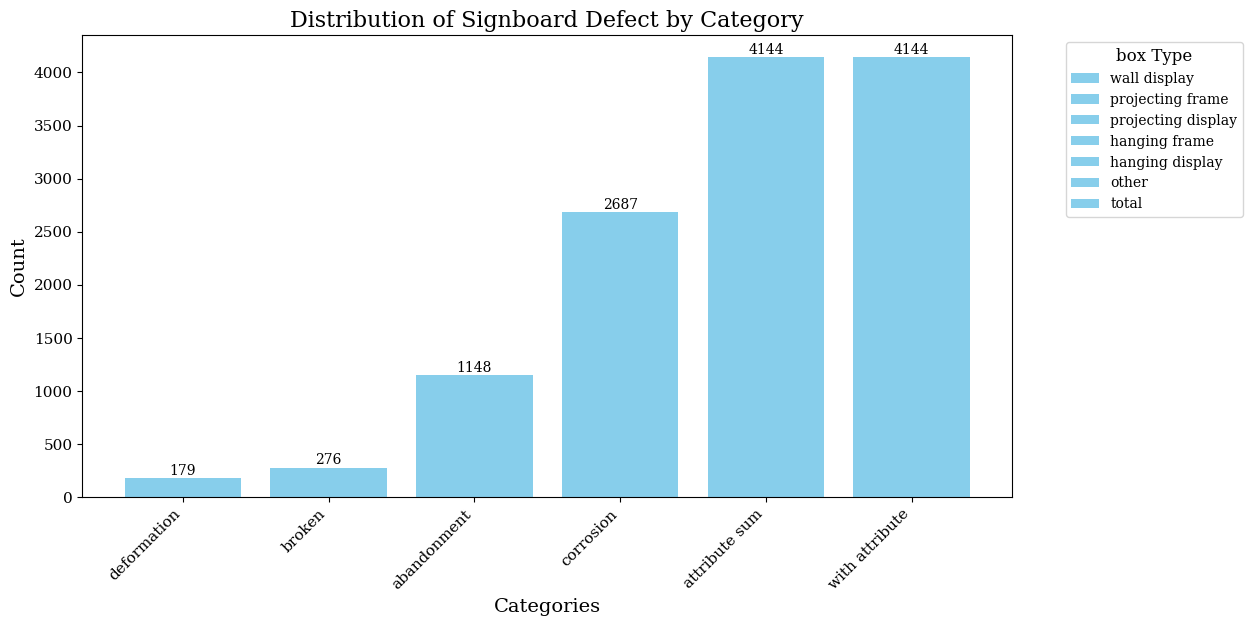

In [5]:
yolo_sta(
    gt_dir=label_v12_dir,
    result_dir=label_v12_dir+'_sta',
    class_path=class_file,
    attribute_path=attribute_file,
    seg=True,
)

In [6]:
copy_all(
    label_v12_dir,
    os.path.join(datav12_dir, 'labels'),
    image_dir,
    os.path.join(datav12_dir, 'images'),
)

copy_all: 100%|██████████| 7946/7946 [00:12<00:00, 641.50it/s] 


In [7]:
output_dir = datav12_dir
output_train_test_path = os.path.join(output_dir, 'train_test.txt')
output_val_test_path = os.path.join(output_dir, 'val_test.txt')
output_train_80p_path = os.path.join(output_dir, 'train_80p_ref.txt')
output_val_80p_path = os.path.join(output_dir, 'val_80p_ref.txt')
output_all_path = os.path.join(output_dir, 'all.txt')
output_all_test_path = os.path.join(output_dir, 'all_test.txt')

copy_split(input_train_test_path, output_train_test_path)
copy_split(input_val_test_path, output_val_test_path)
copy_split(input_train_80p_path, output_train_80p_path)
copy_split(input_val_80p_path, output_val_80p_path)
copy_split(input_all_path, output_all_path)
copy_split(input_all_test_path, output_all_test_path)

shutil.copy(class_c6_path, os.path.join(output_dir, 'class.txt'))
shutil.copy(att_l3_path, os.path.join(output_dir, 'attribute.yaml'))

copy train_test.txt, 7872 records
copy val_test.txt, 80 records
copy train_80p_ref.txt, 7606 records
copy val_80p_ref.txt, 266 records
copy all.txt, 7872 records
copy all_test.txt, 7952 records


'/localnvme/data/billboard/all_data/mseg_c6/data7961_mseg_c6_1106_v12/attribute.yaml'

In [8]:
data_tf_pipline_new(datav12_dir, copy_list=['mseg_c5_l2', 'seg_c5'])

mseg2seg:: 100%|██████████| 7946/7946 [00:10<00:00, 731.99it/s]


In [9]:
output_dir = datav12_dir.replace('mseg_c6', 'mseg_c5_l2')
output_train_test_path = os.path.join(output_dir, 'train_test.txt')
output_val_test_path = os.path.join(output_dir, 'val_test.txt')
output_train_80p_path = os.path.join(output_dir, 'train_80p_ref.txt')
output_val_80p_path = os.path.join(output_dir, 'val_80p_ref.txt')
output_all_path = os.path.join(output_dir, 'all.txt')
output_all_test_path = os.path.join(output_dir, 'all_test.txt')

copy_split(input_train_test_path, output_train_test_path, abs_path=True)
copy_split(input_val_test_path, output_val_test_path, abs_path=True)
copy_split(input_train_80p_path, output_train_80p_path, abs_path=True)
copy_split(input_val_80p_path, output_val_80p_path, abs_path=True)
copy_split(input_all_path, output_all_path, abs_path=True)
copy_split(input_all_test_path, output_all_test_path, abs_path=True)

copy train_test.txt, 7872 records
copy val_test.txt, 80 records
copy train_80p_ref.txt, 7606 records
copy val_80p_ref.txt, 266 records
copy all.txt, 7872 records
copy all_test.txt, 7952 records
